# **Initialization**

In [1]:
# =========================================================
# 1. IMPORTS (Strictly included as requested)
# =========================================================
import os
import sys
import re
import gc
import math
import random
import time as pytime
import contextlib
import csv
import glob
from functools import lru_cache

# --- Third-Party Imports ---
import numpy as np
import pandas as pd
import pulp
import vrplib
import modified_didppy as m_dp
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.optimize import linear_sum_assignment
from numpy.linalg import eigh
from ortools.linear_solver import pywraplp

# --- Library Setup (Adjust path if necessary) ---
LIBRARY_PARENT_PATH = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\THESIS_MODIFIED_DIDP\Evolutionary_algorithm"

if LIBRARY_PARENT_PATH not in sys.path:
    sys.path.append(LIBRARY_PARENT_PATH)
    print(f"📂 Library path added: {LIBRARY_PARENT_PATH}")

try:
    import evolutionary_algorithm_lib
    from evolutionary_algorithm_lib import (
        compile_chromosome_to_useable_function,
        combining_modified_didppy_solver_with_chromosome,
        evolution_algorithm_execution, # Explicitly importing execution function
        EAHyperparameters # Explicitly importing params class
    )
    from evolutionary_algorithm_lib.utils import automatic_creation_of_dual_bounds_registry
    print("✅ Success! 'evolutionary_algorithm_lib' is imported and ready.")
except ImportError as e:
    print(f"❌ Error: Could not import 'evolutionary_algorithm_lib'.\nDetails: {e}")

📂 Library path added: C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\THESIS_MODIFIED_DIDP\Evolutionary_algorithm
✅ Success! 'evolutionary_algorithm_lib' is imported and ready.


# **Data**

In [2]:
# ==========================================
# 2. GLOBAL VARIABLES (Your Naming Convention)
# ==========================================
# --- Problem Setup ---
current_capacity = 1000              # Capacity set to 1000
current_num_locations = 2            # Two locations
current_num_vehicles = 0             # Still zero vehicles (adjust if needed)

# Customer demands: two entries, both 0
current_cust_demands = [0, 0]

# Travel cost: 2x2 matrix with all entries = 0
current_travel_cost = [
    [0, 0],
    [0, 0]
]


# **Model and dual bound declaration**

In [3]:
def creation_of_didp_model_function():
    """
    Creates the CVRP DIDP model and returns it along with necessary metadata 
    for the heuristic functions.
    """
    # =========================================================
    # 1. Define Data
    # =========================================================
    n = current_num_locations
    m = current_num_vehicles
    q = current_capacity
    # Weights (demand)
    d = current_cust_demands

    # Distance matrix
    distance_list = current_travel_cost
    
    # =========================================================
    # 2. Define DIDP model
    # =========================================================
    model = m_dp.Model(float_cost= True)

    customer = model.add_object_type(number=n)
    unvisited_var = model.add_set_var(object_type=customer, target=list(range(1, n)), name='unvisited_customers')
    location_var = model.add_element_var(object_type=customer, target=0)
    load_var = model.add_float_resource_var(target=0, less_is_better=True)
    vehicles_var = model.add_int_resource_var(target=1, less_is_better=True)

    weight = model.add_float_table(d)
    distance_table = model.add_float_table(distance_list)

    model.add_base_case([unvisited_var.is_empty(), location_var == 0])

    for j in range(1, n):
        visit = m_dp.Transition(
            name=f"visit {j}",
            cost=distance_table[location_var, j] + m_dp.FloatExpr.state_cost(),
            effects=[
                (unvisited_var, unvisited_var.remove(j)),
                (location_var, j),
                (load_var, load_var + weight[j]),
            ],
            preconditions=[unvisited_var.contains(j), load_var + weight[j] <= q],
        )
        model.add_transition(visit)

    for j in range(1, n):
        visit_via_depot = m_dp.Transition(
            name=f"visit {j} with new vehicle",
            cost=distance_table[location_var, 0] + distance_table[0, j] + m_dp.FloatExpr.state_cost(),
            effects=[
                (unvisited_var, unvisited_var.remove(j)),
                (location_var, j),
                (load_var, weight[j]),
                (vehicles_var, vehicles_var + 1),
            ],
            preconditions=[unvisited_var.contains(j), vehicles_var < m],
        )
        model.add_transition(visit_via_depot)

    return_to_depot = m_dp.Transition(
        name="return",
        cost=distance_table[location_var, 0] + m_dp.FloatExpr.state_cost(),
        effects=[(location_var, 0)],
        preconditions=[unvisited_var.is_empty(), location_var != 0],
    )
    model.add_transition(return_to_depot)

    model.add_state_constr((m - vehicles_var + 1) * q - load_var >= weight[unvisited_var])

    # =========================================================
    # 3. Bundle Metadata
    # =========================================================
    metadata = {
        "unvisited_var": unvisited_var,
        "location_var": location_var,
        "distance_matrix": distance_list,
        "demand": d,
        "capacity": q,
        "num_vehicles": m,
        "num_nodes": n
    }
    
    didp_bundle = (model, metadata)
    return didp_bundle

In [4]:
def create_persistent_lp_relaxation_3_index_dual_bounds(metadata):
    """
    Creates a persistent 3-Index CVRP Relaxation (Vehicle-Node-Node).
    - Logic: VRP4 Model (Assignment + Flow + MTZ Capacity).
    - Pattern: Cached internal worker '_solve_3idx'.
    """
    # --- Extract Static Data ---
    n_nodes = metadata['num_nodes']
    n_vehicles = metadata['num_vehicles']
    capacity = metadata['capacity']
    demands = metadata['demand']
    dist_matrix = metadata['distance_matrix']
    
    unvisited_var = metadata['unvisited_var']
    location_var = metadata['location_var']

    # --- INITIALIZATION (Runs Once) ---
    solver = pywraplp.Solver.CreateSolver('GLOP')
    if not solver:
        return lambda state: 0.0

    infinity = solver.infinity()

    # --- Variables ---
    x = {} # Flow x_k_i_j
    y = {} # Assignment y_i_k
    u = {} # Load u_i_k

    # 1. Flow
    for k in range(n_vehicles):
        for i in range(n_nodes):
            for j in range(n_nodes):
                if i != j: x[(k, i, j)] = solver.NumVar(0, 1, f'x_{k}_{i}_{j}')

    # 2. Assignment (All nodes, All vehicles)
    for i in range(n_nodes):
        for k in range(n_vehicles):
            y[(i, k)] = solver.NumVar(0, 1, f'y_{i}_{k}')

    # 3. Potentials (Load)
    for i in range(1, n_nodes):
        for k in range(n_vehicles):
            u[(i, k)] = solver.NumVar(0, capacity, f'u_{i}_{k}')

    # --- Constraints ---
    
    # (1.29) Customer Assignment (Mutable)
    # This is what we toggle on/off based on the state.
    cons_assignment = {}
    for i in range(1, n_nodes):
        c = solver.Constraint(0, 0, f'assign_{i}')
        for k in range(n_vehicles): c.SetCoefficient(y[(i, k)], 1)
        cons_assignment[i] = c

    # (1.30) Depot Usage
    c_depot = solver.Constraint(0, n_vehicles, 'depot_usage')
    for k in range(n_vehicles): c_depot.SetCoefficient(y[(0, k)], 1)

    # (1.31) Flow Conservation
    for k in range(n_vehicles):
        for i in range(n_nodes):
            # Out
            c_out = solver.Constraint(0, 0, f'flow_out_{i}_{k}')
            c_out.SetCoefficient(y[(i, k)], -1)
            for j in range(n_nodes):
                if i != j: c_out.SetCoefficient(x[(k, i, j)], 1)
            
            # In
            c_in = solver.Constraint(0, 0, f'flow_in_{i}_{k}')
            c_in.SetCoefficient(y[(i, k)], -1)
            for j in range(n_nodes):
                if i != j: c_in.SetCoefficient(x[(k, j, i)], 1)

    # (1.37) & (1.38) MTZ Capacity
    for k in range(n_vehicles):
        for i in range(1, n_nodes):
            for j in range(1, n_nodes):
                if i != j:
                    c = solver.Constraint(-infinity, float(capacity - demands[j]), f'mtz_{k}_{i}_{j}')
                    c.SetCoefficient(u[(i, k)], 1)
                    c.SetCoefficient(u[(j, k)], -1)
                    c.SetCoefficient(x[(k, i, j)], capacity)

    # --- Objective ---
    objective = solver.Objective()
    for k in range(n_vehicles):
        for i in range(n_nodes):
            for j in range(n_nodes):
                if i != j: objective.SetCoefficient(x[(k, i, j)], dist_matrix[i][j])
    objective.SetMinimization()

    # ==========================================
    # 2. CACHED SOLVER WORKER
    # ==========================================
    @lru_cache(maxsize=10000)
    def _solve_3idx(active_tuple):
        """
        Internal worker: Sets bounds and solves.
        active_tuple: Tuple of customer indices that MUST be visited.
        """
        active_set = set(active_tuple)

        # Reset/Update Assignment Constraints
        for i in range(1, n_nodes):
            if i in active_set:
                # ACTIVE: Must be visited
                cons_assignment[i].SetBounds(1, 1)
                # Load variables active
                for k in range(n_vehicles):
                    u[(i, k)].SetBounds(demands[i], capacity)
            else:
                # INACTIVE: Must NOT be visited (flow = 0)
                cons_assignment[i].SetBounds(0, 0)
                # Load variables forced to 0
                for k in range(n_vehicles):
                    u[(i, k)].SetBounds(0, 0)

        # Solve
        solver.SetTimeLimit(100) # 100ms
        status = solver.Solve()
        
        if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:
            return float(objective.Value())
        return 0.0

    # ==========================================
    # 3. HEURISTIC WRAPPER
    # ==========================================
    def h_lp_relaxation_3_idx(state):
        unvisited = state[unvisited_var]
        current_loc = state[location_var]
        
        # Optimization: Solved state
        if not unvisited and current_loc == 0: 
            return 0.0

        # Define Active Set: Unvisited + Current (if not depot)
        active_customers = set(unvisited)
        if current_loc != 0:
            active_customers.add(current_loc)
        
        # Create Tuple Key
        active_key = tuple(sorted(list(active_customers)))
        
        return _solve_3idx(active_key)

    return h_lp_relaxation_3_idx

def create_persistent_lp_relaxation_2_index_dual_bounds(metadata):
    """
    Creates a persistent 2-Index CVRP Relaxation (Flow-based).
    - Logic: Aggregated Flow (No Vehicle Dimension).
    - Pattern: Cached internal worker '_solve_2idx'.
    """
    # --- Extract Static Data ---
    n_nodes = metadata['num_nodes']
    n_vehicles = metadata['num_vehicles']
    capacity = metadata['capacity']
    demands = metadata['demand']
    dist_matrix = metadata['distance_matrix']
    unvisited_var = metadata['unvisited_var']

    # --- INITIALIZATION ---
    solver = pywraplp.Solver.CreateSolver('GLOP')
    if not solver:
        return lambda state: 0.0

    infinity = solver.infinity()

    # --- Variables ---
    x = {} # Flow x_i_j
    u = {} # Load u_i

    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j: x[(i, j)] = solver.NumVar(0, 1, f'x_{i}_{j}')

    for i in range(1, n_nodes):
        u[i] = solver.NumVar(0, capacity, f'u_{i}')

    # --- Constraints ---
    cons_degree_out = {}
    cons_degree_in = {}

    # 1. Degree Constraints (Mutable)
    for i in range(1, n_nodes):
        # Outgoing
        c_out = solver.Constraint(0, 0, f'deg_out_{i}')
        for j in range(n_nodes):
            if i != j: c_out.SetCoefficient(x[(i, j)], 1)
        cons_degree_out[i] = c_out

        # Incoming
        c_in = solver.Constraint(0, 0, f'deg_in_{i}')
        for j in range(n_nodes):
            if i != j: c_in.SetCoefficient(x[(j, i)], 1)
        cons_degree_in[i] = c_in

    # 2. Depot Degree
    c_depot_out = solver.Constraint(0, n_vehicles, 'depot_out')
    c_depot_in = solver.Constraint(0, n_vehicles, 'depot_in')
    for j in range(1, n_nodes):
        c_depot_out.SetCoefficient(x[(0, j)], 1)
        c_depot_in.SetCoefficient(x[(j, 0)], 1)

    # 3. MTZ Capacity
    for i in range(1, n_nodes):
        for j in range(1, n_nodes):
            if i != j:
                c = solver.Constraint(-infinity, float(capacity - demands[j]), f'mtz_{i}_{j}')
                c.SetCoefficient(u[j], 1)
                c.SetCoefficient(u[i], -1)
                c.SetCoefficient(x[(i, j)], capacity)

    # --- Objective ---
    objective = solver.Objective()
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j: objective.SetCoefficient(x[(i, j)], dist_matrix[i][j])
    objective.SetMinimization()

    # ==========================================
    # 2. CACHED SOLVER WORKER
    # ==========================================
    @lru_cache(maxsize=10000)
    def _solve_2idx(active_tuple):
        active_set = set(active_tuple)

        # Reset/Update Constraints
        for i in range(1, n_nodes):
            if i in active_set:
                # ACTIVE
                cons_degree_out[i].SetBounds(1, 1)
                cons_degree_in[i].SetBounds(1, 1)
                u[i].SetBounds(demands[i], capacity)
            else:
                # INACTIVE
                cons_degree_out[i].SetBounds(0, 0)
                cons_degree_in[i].SetBounds(0, 0)
                u[i].SetBounds(0, 0)
        
        solver.SetTimeLimit(100)
        status = solver.Solve()
        
        if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:
            return float(objective.Value())
        return 0.0

    # ==========================================
    # 3. HEURISTIC WRAPPER
    # ==========================================
    def h_lp_relaxation_2_idx(state):
        unvisited = state[unvisited_var]
        
        if not unvisited: return 0.0

        # Define Active Set: Unvisited
        # Note: 2-index relaxation often ignores "current location" specific routing logic 
        # and just solves the flow problem for the remaining set.
        active_key = tuple(sorted(list(unvisited)))

        return _solve_2idx(active_key)

    return h_lp_relaxation_2_idx

def dual_bound_expression_function(didp_bundle):
    """ 
    Registry containing ALL heuristics (Combinatorial + LP) for CVRP.
    """
    model, metadata = didp_bundle
    
    # Extract metadata
    unvisited_var = metadata['unvisited_var']
    location_var = metadata['location_var']
    distance_list = metadata['distance_matrix']
    cost_matrix = np.array(distance_list)
    demand = metadata['demand']
    capacity = metadata['capacity']
    num_vehicles = metadata['num_vehicles']
    n_nodes = metadata['num_nodes']

    # Pre-computation
    masked_cost = cost_matrix.astype(float).copy()
    np.fill_diagonal(masked_cost, np.inf)
    min_outgoing_arr = np.min(masked_cost, axis=1)
    min_incoming_arr = np.min(masked_cost, axis=0)

    # --- Initialize LP Bounds ---
    h_lp_3idx = create_persistent_lp_relaxation_3_index_dual_bounds(metadata)
    h_lp_2idx = create_persistent_lp_relaxation_2_index_dual_bounds(metadata)

    # ==========================================
    # COMBINATORIAL BOUNDS (Internal Workers)
    # ==========================================

    # --- Flow Bound ---
    @lru_cache(maxsize=100000)
    def _calc_flow(unvisited_tuple):
        s = sum(demand[v] * distance_list[0][v] for v in unvisited_tuple)
        return float(round((2.0 / capacity) * s))

    def h_flow(state):
        U = state[unvisited_var]
        return _calc_flow(tuple(sorted(list(U)))) if U else 0.0

    # --- Degree Average Bound ---
    @lru_cache(maxsize=100000)
    def _calc_degree(active_tuple):
        nodes = list(active_tuple)
        sub_mat = cost_matrix[np.ix_(nodes, nodes)].astype(float)
        np.fill_diagonal(sub_mat, np.inf)
        sum_in = np.sum(np.min(sub_mat, axis=0))
        sum_out = np.sum(np.min(sub_mat, axis=1))
        return float(0.5 * (sum_in + sum_out))

    def h_degree_average(state):
        U = state[unvisited_var]
        curr = state[location_var]
        if not U and curr == 0: return 0.0
        
        # Active: Current -> Unvisited -> Depot
        active = set(U)
        active.add(curr)
        active.add(0)
        return _calc_degree(tuple(sorted(list(active))))

    # --- Global Min Flow ---
    @lru_cache(maxsize=100000)
    def _calc_min_flow_static(unvisited_tuple):
        val_out = sum(min_outgoing_arr[u] for u in unvisited_tuple)
        val_in = sum(min_incoming_arr[u] for u in unvisited_tuple)
        return val_out, val_in

    def h_global_min_flow(state):
        U = state[unvisited_var]
        curr = state[location_var]
        if not U and curr == 0: return 0.0
        
        # Get static part
        val_out, val_in = _calc_min_flow_static(tuple(sorted(list(U))))
        
        # Add dynamic part (Current)
        if curr != 0:
            val_out += min_outgoing_arr[curr]
            val_in += min_incoming_arr[0]
            
        return float(max(val_out, val_in))

    # --- MST Bound ---
    @lru_cache(maxsize=100000)
    def _calc_mst(unvisited_tuple):
        if not unvisited_tuple: return 0.0
        nodes = [0] + list(unvisited_tuple)
        sub_mat = cost_matrix[np.ix_(nodes, nodes)]
        mst = minimum_spanning_tree(sub_mat)
        return float(mst.sum())

    def h_mst(state):
        U = state[unvisited_var]
        return _calc_mst(tuple(sorted(list(U))))

    # --- 1-Tree Bound ---
    @lru_cache(maxsize=100000)
    def _calc_1tree(unvisited_tuple):
        subset = list(unvisited_tuple)
        depot_edges = sorted(cost_matrix[0, subset])
        e1 = depot_edges[0]
        e2 = depot_edges[1] if len(depot_edges) > 1 else 0.0
        
        if len(subset) > 1:
            sub_mat = cost_matrix[np.ix_(subset, subset)]
            mst_val = minimum_spanning_tree(sub_mat).sum()
        else:
            mst_val = 0.0
        return float(mst_val + e1 + e2)

    def h_1tree(state):
        U = state[unvisited_var]
        if not U: return 0.0
        return _calc_1tree(tuple(sorted(list(U))))

    # --- Assignment Bound ---
    @lru_cache(maxsize=100000)
    def _calc_assignment(unvisited_tuple):
        nodes = [0] + list(unvisited_tuple)
        sub_mat = cost_matrix[np.ix_(nodes, nodes)]
        assign_mat = sub_mat.astype(float).copy()
        np.fill_diagonal(assign_mat, np.inf)
        row, col = linear_sum_assignment(assign_mat)
        return float(assign_mat[row, col].sum())

    def h_assignment(state):
        U = state[unvisited_var]
        if not U: return 0.0
        return _calc_assignment(tuple(sorted(list(U))))

    # --- Eigenvalue Bound ---
    @lru_cache(maxsize=100000)
    def _calc_eigen(unvisited_tuple):
        nodes = [0] + list(unvisited_tuple)
        N = len(nodes)
        if N < 2: return 0.0
        
        D_sub = cost_matrix[np.ix_(nodes, nodes)]
        one = np.ones((N, 1))
        P = np.eye(N) - (one @ one.T) / N
        M = -P @ D_sub @ P
        M = (M + M.T) / 2
        try:
            eigvals = np.flip(eigh(M)[0])
        except np.linalg.LinAlgError:
            return 0.0
        
        eigvals = eigvals[np.abs(eigvals) > 1e-9]
        coeffs = np.array([1 - np.cos(2 * np.pi * k / N) for k in range(1, N)])
        
        phi = 0.0
        if N > 1:
            if N % 2 == 1:
                num_terms = (N - 1) // 2
                if 2 * num_terms <= len(eigvals) and num_terms <= len(coeffs):
                     phi = sum(coeffs[k-1] * (eigvals[2*k - 2] + eigvals[2*k - 1]) for k in range(1, num_terms + 1))
            else:
                num_sum_terms = N // 2 - 1
                if 2 * num_sum_terms < len(eigvals) and num_sum_terms <= len(coeffs):
                    phi = sum(coeffs[k-1] * (eigvals[2*k - 2] + eigvals[2*k - 1]) for k in range(1, num_sum_terms + 1))
                    if N-2 < len(eigvals): phi += 2 * eigvals[N - 2]
                elif N > 1 and N-2 < len(eigvals):
                    phi = 2 * eigvals[N - 2]
        return float(phi)

    def h_eigen(state):
        U = state[unvisited_var]
        if not U: return 0.0
        return _calc_eigen(tuple(sorted(list(U))))

    # Return Registry
    return automatic_creation_of_dual_bounds_registry(locals())

# Execution Line
dual_bound_functions_registry = dual_bound_expression_function(creation_of_didp_model_function())
display(dual_bound_functions_registry)

{'h_lp_3idx': <function __main__.create_persistent_lp_relaxation_3_index_dual_bounds.<locals>.h_lp_relaxation_3_idx(state)>,
 'h_lp_2idx': <function __main__.create_persistent_lp_relaxation_2_index_dual_bounds.<locals>.h_lp_relaxation_2_idx(state)>,
 'h_flow': <function __main__.dual_bound_expression_function.<locals>.h_flow(state)>,
 'h_degree_average': <function __main__.dual_bound_expression_function.<locals>.h_degree_average(state)>,
 'h_global_min_flow': <function __main__.dual_bound_expression_function.<locals>.h_global_min_flow(state)>,
 'h_mst': <function __main__.dual_bound_expression_function.<locals>.h_mst(state)>,
 'h_1tree': <function __main__.dual_bound_expression_function.<locals>.h_1tree(state)>,
 'h_assignment': <function __main__.dual_bound_expression_function.<locals>.h_assignment(state)>,
 'h_eigen': <function __main__.dual_bound_expression_function.<locals>.h_eigen(state)>}

# **Original Hyperparameters**

In [5]:
# ==========================================
# 1. EVOLUTIONARY ALGORITHM HYPERPARAMETERS
# ==========================================
POPULATION_SIZE = 15       # Size of the population in each generation
GENERATIONS = 10      # Number of generations to run
MUTATION_RATE = 0.2         # Probability of mutating an individual
CROSSOVER_RATE = 0.8        # Probability of performing crossover
ELITISM_RATE = 0.10
# ==========================================
# 2. OPERATOR PARAMETERS
# ==========================================
# Bounds for the coefficients generated for weighted blocks (e.g., 5.5 * h1)
LB_range_of_constant = 0.0  
UB_range_of_constant = 10.0 
# Depth limits for the RPN trees (used in Ramped Half-and-Half generator)
min_chromosome_length = 2               # Minimum depth of the initial trees
max_chromosome_length = 10               # Maximum depth of the initial trees
# Probability of selecting the best individual in the  tournament selection
# Tournament size for parent selection
tournament_size=random.randint(2, 10)
tournament_probability=0.8
# Mutation: Maximum depth allowed for the *newly generated* subtree during mutation
mutation_max_subtree_depth = random.randint(min_chromosome_length, max_chromosome_length)  # Randomly chosen between 1 and 3
# 1-Point Crossover: Probability of using Homology (matching structure) vs Random fallback
homology_1_point_crossover_probability = 0.5
# Subtree Crossover: Probability of swapping a Function (Branch) vs Terminal (Leaf)
subtree_crossover_probability = 0.9
# Uniform Crossover: Probability of swapping genes at a specific index
uniform_crossover_probability = 0.5
# ==========================================
# 4. OTHER PARAMETERS
# ==========================================
# The Ground Truth optimal cost for the specific problem instance
# Used to calculate fitness (deviation from optimal)
OPTIMAL_COST_REFERENCE= 0
# Time limit (in seconds) for the DIDP solver to run per chromosome evaluation
SOLVER_TIME_LIMIT = 10 #seconds

# **Sensitivity Execution**

In [6]:
import os
import csv
import pandas as pd
import time as pytime
import gc
import contextlib
import random
import re
import vrplib 

# =========================================================
# 1. SENSITIVITY CONFIGURATION (ADJUST THIS BLOCK)
# =========================================================
INSTANCE_NAME = "A-n55-k9.vrp"

# Define what we are testing
SENSITIVITY_CONFIG = {
    "target_param": "ub_range_of_constant",          # Key must match EAHyperparameters argument name
    "base_value": 10,                       # The original value used in the baseline run
    "test_values": [ 6, 7, 8, 9, 10, 11, 12, 13, 14], # List of values to test
    "output_csv": "CVRP_sensitivity_ub_range_of_constant_results.csv",
    "logs_dir": "CVRP_sensitivity_ub_range_of_constant_logs"
}

# Default Hyperparameters (Will be overridden by SENSITIVITY_CONFIG['target_param'])
DEFAULT_PARAMS = {
    "population_size": POPULATION_SIZE,
    "generations": GENERATIONS,
    "crossover_rate": CROSSOVER_RATE,
    "mutation_rate": MUTATION_RATE,
    "elitism_rate": ELITISM_RATE,
    "lb_range_of_constant": LB_range_of_constant,
    "ub_range_of_constant": UB_range_of_constant,
    "min_chromosome_length": min_chromosome_length,
    "max_chromosome_length": max_chromosome_length,
    "tournament_size": tournament_size, # Fixed default for sensitivity (or use random range if preferred)
    "tournament_probability": tournament_probability,
    "mutation_max_subtree_depth": mutation_max_subtree_depth,
    "homology_1_point_crossover_probability": homology_1_point_crossover_probability,
    "subtree_crossover_probability": subtree_crossover_probability,
    "uniform_crossover_probability": uniform_crossover_probability,
    "solver_time_limit": SOLVER_TIME_LIMIT,
    "available_operations": ["ADD", "SUBTRACT", "MAX", "MIN", "MULTIPLY", "PDIV"]
}

# Directories & Reference
SEARCH_DIRS = [
    r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\3_CVRP_dual_bounds_and_models\Datasets\A",
    r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\3_CVRP_dual_bounds_and_models\Datasets\X",
]
REF_RESULT_CSV = "result_CVRP_EA_dual_bound.csv"

# Ensure Logs Directory Exists
if not os.path.exists(SENSITIVITY_CONFIG["logs_dir"]):
    os.makedirs(SENSITIVITY_CONFIG["logs_dir"])

# =========================================================
# 2. HELPER UTILITIES
# =========================================================
def update_globals_for_cvrp(file_path):
    """Updates the specific global variables required by creation_of_didp_model_function."""
    global current_capacity, current_num_locations, current_num_vehicles, current_cust_demands, current_travel_cost, current_optimal_cost
    
    instance = vrplib.read_instance(file_path)
    
    # 1. Update Capacity & Dimensions
    current_capacity = float(instance['capacity'])
    current_num_locations = int(instance['dimension'])
    
    # 2. Update Num Vehicles (Regex or Fallback)
    match_trucks = re.search(r"No of trucks:\s*(\d+)", str(instance.get('comment', '')))
    if match_trucks:
        current_num_vehicles = int(match_trucks.group(1))
    else:
        match_filename = re.search(r"-k(\d+)", os.path.basename(file_path))
        if match_filename:
            current_num_vehicles = int(match_filename.group(1))
        else:
            current_num_vehicles = 1 # Fallback
            
    # 3. Update Demands & Costs
    current_cust_demands = [float(x) for x in instance['demand']]
    current_travel_cost = [[float(x) for x in row] for row in instance['edge_weight']]
    
    return True

def find_file_in_dirs(instance_name, search_dirs):
    for folder in search_dirs:
        path = os.path.join(folder, instance_name)
        if os.path.exists(path): return path
    return None

def get_baseline_data(csv_path, instance_name):
    """Returns: (fitness, chromosome_string)"""
    if not os.path.exists(csv_path):
        print(f"⚠️ Reference CSV {csv_path} not found. Defaulting to 0.0")
        return 0.0, "NOT_FOUND"
    try:
        df = pd.read_csv(csv_path)
        df.columns = [c.strip() for c in df.columns]
        row = df[df['Instance'] == instance_name]
        if not row.empty:
            fit = float(row.iloc[0]['Best_Fitness'])
            chrom = str(row.iloc[0].get('Best_Chromosome', 'UNKNOWN'))
            return fit, chrom
    except Exception as e:
        print(f"⚠️ Could not read baseline data: {e}")
    return 0.0, "ERROR"

def get_processed_values(output_csv):
    """Returns a set of tested parameter values that are already finished."""
    processed = set()
    if os.path.exists(output_csv):
        try:
            df = pd.read_csv(output_csv)
            if 'Changed_parameter' in df.columns:
                # Handle float vs int types loosely
                processed = set(df['Changed_parameter'].tolist())
        except: pass
    return processed

# =========================================================
# 3. MAIN EXECUTION LOOP
# =========================================================

# A. Locate File & Update Globals
file_path = find_file_in_dirs(INSTANCE_NAME, SEARCH_DIRS)
if not file_path:
    raise FileNotFoundError(f"Could not find {INSTANCE_NAME} in search directories.")

print(f"📄 Found instance at: {file_path}")
update_globals_for_cvrp(file_path)

# B. Get Baseline Data
original_fitness, original_chromosome = get_baseline_data(REF_RESULT_CSV, INSTANCE_NAME)
optimal_cost = 1073.0 # Hardcoded for A-n55-k9

# C. Resume Check
output_csv = SENSITIVITY_CONFIG["output_csv"]
processed_values = get_processed_values(output_csv)

target_param = SENSITIVITY_CONFIG["target_param"]
base_value = SENSITIVITY_CONFIG["base_value"]

print(f"🚀 Starting Sensitivity Analysis: {target_param}")
print(f"   -> Base Value: {base_value}")
print(f"   -> Original Fitness: {original_fitness}")
print(f"   -> Processed: {len(processed_values)}")

# D. Iterate
for test_val in SENSITIVITY_CONFIG["test_values"]:
    # 1. Resume Check
    if test_val in processed_values:
        continue

    print(f"\n🧪 Testing {target_param} = {test_val} ...")
    
    # 2. Setup Log
    log_file_name = f"{INSTANCE_NAME}_{target_param}_{test_val}_log.txt"
    log_path = os.path.join(SENSITIVITY_CONFIG["logs_dir"], log_file_name)

    try:
        # --- BASE CASE LOGIC ---
        if test_val == base_value:
            print(f"   -> Base parameter detected ({test_val}). Skipping run and logging baseline.")
            new_fitness = original_fitness
            best_ind_chrom = original_chromosome
            pct_change_param = 0.0
            pct_change_fitness = 0.0
            
            with open(log_path, "w", encoding="utf-8") as f:
                f.write(f"Base case {target_param}={test_val}. Skipped execution. Logged original fitness: {original_fitness}")

        else:
            # --- PREPARE PARAMS ---
            # Copy defaults and override the target parameter
            current_params = DEFAULT_PARAMS.copy()
            current_params[target_param] = test_val
            
            # Construct EAHyperparameters object dynamically
            params = EAHyperparameters(
                population_size=current_params['population_size'],
                generations=current_params['generations'],
                crossover_rate=current_params['crossover_rate'],
                mutation_rate=current_params['mutation_rate'],
                elitism_rate=current_params['elitism_rate'],
                lb_range_of_constant=current_params['lb_range_of_constant'],
                ub_range_of_constant=current_params['ub_range_of_constant'],
                min_chromosome_length=current_params['min_chromosome_length'],
                max_chromosome_length=current_params['max_chromosome_length'],
                tournament_size=current_params['tournament_size'],
                tournament_probability=current_params['tournament_probability'],
                # Dynamic random calc if needed, else fixed
                mutation_max_subtree_depth=current_params['mutation_max_subtree_depth'],
                homology_1_point_crossover_probability=current_params['homology_1_point_crossover_probability'],
                subtree_crossover_probability=current_params['subtree_crossover_probability'],
                uniform_crossover_probability=current_params['uniform_crossover_probability'],
                reference_point=optimal_cost,
                solver_time_limit=current_params['solver_time_limit'],
                available_operations=current_params['available_operations']
            )

            # --- RUN EA ---
            start_time = pytime.time()
            with open(log_path, "w", encoding="utf-8", buffering=1) as f:
                with contextlib.redirect_stdout(f):
                    best_ind = evolution_algorithm_execution(
                        didp_model_registry=creation_of_didp_model_function,
                        dual_bound_expression_function=dual_bound_expression_function,
                        params=params
                    )
            
            # --- METRICS ---
            new_fitness = best_ind.get('fitness', 0.0)
            best_ind_chrom = str(best_ind.get('chromosome', "FAILED"))
            if new_fitness is None: new_fitness = 0.0
            
            # % Change Calculation
            if base_value != 0:
                pct_change_param = ((test_val - base_value) / base_value) * 100
            else:
                pct_change_param = 0.0 # Avoid div by zero
            
            if original_fitness != 0:
                pct_change_fitness = ((new_fitness - original_fitness) / original_fitness) * 100
            else:
                pct_change_fitness = 0.0

        # 6. Save Results
        result_row = {
            "Instance number": INSTANCE_NAME,
            "Changed_parameter": test_val,
            "Original_fitness": original_fitness,
            "Sensitivity_fitness": new_fitness,
            "percentage_of_change_of_parameter": f"{pct_change_param:.2f}%",
            "percentage_of_change_of_fitness": f"{pct_change_fitness:.2f}%",
            "absolute_percentage_of_change_of_fitness": f"{abs(pct_change_fitness):.2f}%",
            "sensitivity_chromosome": best_ind_chrom
        }

        file_exists = os.path.exists(output_csv)
        with open(output_csv, mode='a', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=result_row.keys())
            if not file_exists:
                writer.writeheader()
            writer.writerow(result_row)

        print(f"   ✅ Done. Fitness: {new_fitness:.4f} (Change: {pct_change_fitness:.2f}%)")
        processed_values.add(test_val)

    except Exception as e:
        print(f"   ❌ Failed: {e}")
        import traceback
        traceback.print_exc()

    finally:
        gc.collect()

print("\n🎉 Sensitivity Analysis Complete!")

📄 Found instance at: C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\3_CVRP_dual_bounds_and_models\Datasets\A\A-n55-k9.vrp
🚀 Starting Sensitivity Analysis: ub_range_of_constant
   -> Base Value: 10
   -> Original Fitness: 0.1064591607095857
   -> Processed: 0

🧪 Testing ub_range_of_constant = 6 ...
   ✅ Done. Fitness: 0.1087 (Change: 2.12%)

🧪 Testing ub_range_of_constant = 7 ...
   ✅ Done. Fitness: 0.1065 (Change: 0.00%)

🧪 Testing ub_range_of_constant = 8 ...
   ✅ Done. Fitness: 0.1065 (Change: 0.00%)

🧪 Testing ub_range_of_constant = 9 ...
   ✅ Done. Fitness: 0.0696 (Change: -34.63%)

🧪 Testing ub_range_of_constant = 10 ...
   -> Base parameter detected (10). Skipping run and logging baseline.
   ✅ Done. Fitness: 0.1065 (Change: 0.00%)

🧪 Testing ub_range_of_constant = 11 ...
   ✅ Done. Fitness: 0.1065 (Change: 0.00%)

🧪 Testing ub_range_of_constant = 12 ...
   ✅ Done. Fitness: 0.1065 (Change: 0.00%)

🧪 Testing ub_range_of_

# **Visualization**

Graph 1 saved as: Sensitivity_Upper_bound_of_constant_rangee_Fitness.png


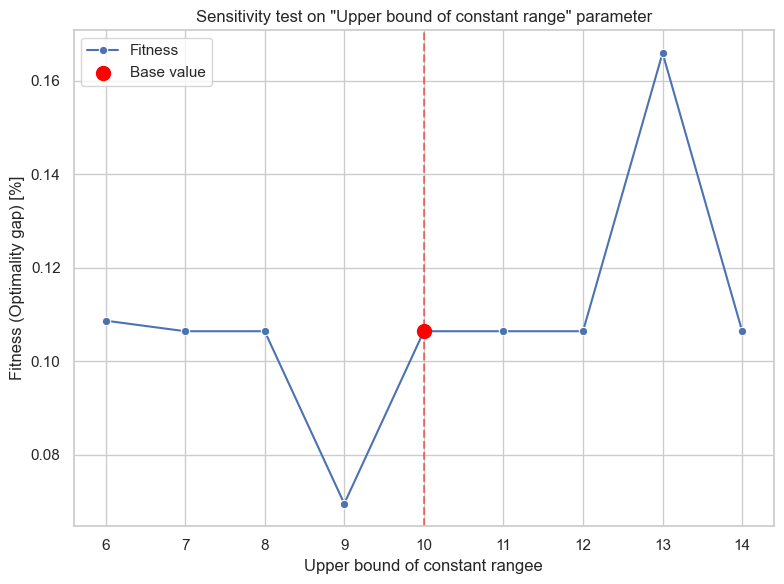

Graph 2 saved as: Sensitivity_Upper_bound_of_constant_rangee_Fitness_PctChange.png


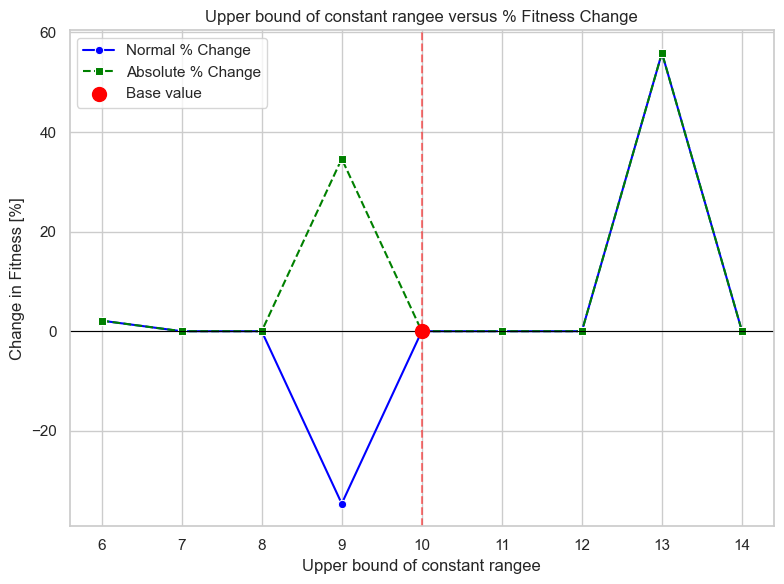

Graph 3 saved as: Sensitivity_Upper_bound_of_constant_rangee_Param_PctChange.png


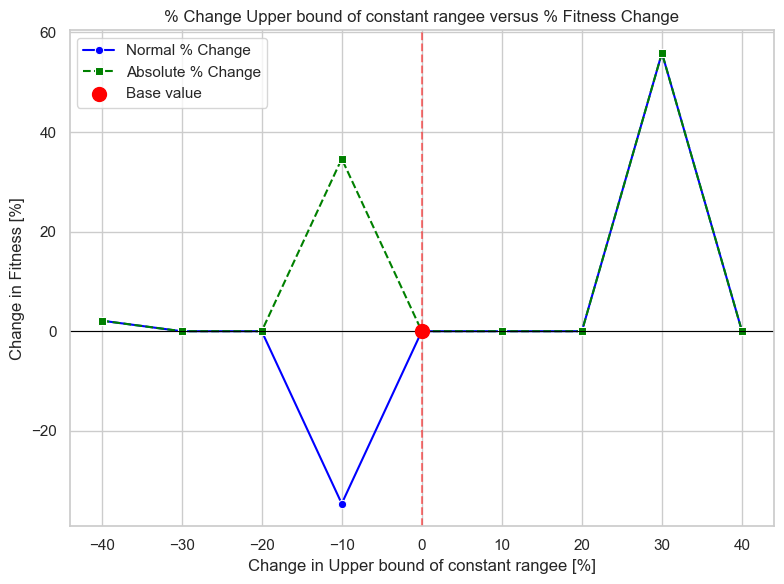

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_sensitivity_analysis(csv_path, parameter_label="Upper bound of constant range"):
    """
    Generates three separate sensitivity analysis graphs from a results CSV.
    
    Args:
        csv_path (str): Path to the results CSV file.
        parameter_label (str): Label for the x-axis (e.g., 'Population Size', 'Mutation Rate').
    """
    # 1. Load Data
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: File {csv_path} not found.")
        return

    # 2. Data Cleaning & Preprocessing
    # Helper to clean percentage strings
    def clean_pct(val):
        if isinstance(val, str):
            return float(val.strip('%'))
        return float(val)

    # Convert percentage columns to floats
    df['pct_change_param_numeric'] = df['percentage_of_change_of_parameter'].apply(clean_pct)
    df['pct_change_fitness_numeric'] = df['percentage_of_change_of_fitness'].apply(clean_pct)
    
    # Handle absolute percentage (strip % if string, else use float)
    if 'absolute_percentage_of_change_of_fitness' in df.columns:
        df['abs_pct_change_fitness_numeric'] = df['absolute_percentage_of_change_of_fitness'].apply(clean_pct)
    else:
        # Fallback if column missing
        df['abs_pct_change_fitness_numeric'] = df['pct_change_fitness_numeric'].abs()

    # Identify Baseline (where % change of parameter is 0)
    baseline_row = df[df['pct_change_param_numeric'] == 0.0]
    
    if not baseline_row.empty:
        base_param_val = baseline_row.iloc[0]['Changed_parameter']
        base_fitness_val = baseline_row.iloc[0]['Sensitivity_fitness']
    else:
        base_param_val = None
        base_fitness_val = None

    # Setup Plot Style
    sns.set_theme(style="whitegrid")
    clean_label = parameter_label.replace(' ', '_')

    # =========================================================
    # Graph 1: Parameter Value vs Fitness
    # =========================================================
    plt.figure(figsize=(8, 6))
    
    sns.lineplot(data=df, x='Changed_parameter', y='Sensitivity_fitness', marker='o', label='Fitness')
    
    # Highlight Baseline
    if base_param_val is not None:
        plt.scatter([base_param_val], [base_fitness_val], color='red', s=100, zorder=5, label='Base value')
        plt.axvline(base_param_val, color='red', linestyle='--', alpha=0.5)
    
    plt.title(f'Sensitivity test on "Upper bound of constant range" parameter')
    plt.xlabel(parameter_label)
    plt.ylabel('Fitness (Optimality gap) [%]')
    plt.legend()
    plt.tight_layout()
    
    output_img_1 = f"Sensitivity_{clean_label}_Fitness.png"
    plt.savefig(output_img_1)
    print(f"Graph 1 saved as: {output_img_1}")
    plt.show()

    # =========================================================
    # Graph 2: Parameter Value vs % Change of Fitness
    # =========================================================
    plt.figure(figsize=(8, 6))
    
    sns.lineplot(data=df, x='Changed_parameter', y='pct_change_fitness_numeric', 
                 marker='o', label='Normal % Change', color='blue')
    sns.lineplot(data=df, x='Changed_parameter', y='abs_pct_change_fitness_numeric', 
                 marker='s', linestyle='--', label='Absolute % Change', color='green')

    # Highlight Baseline
    if base_param_val is not None:
        plt.scatter([base_param_val], [0], color='red', s=100, zorder=5, label='Base value')
        plt.axvline(base_param_val, color='red', linestyle='--', alpha=0.5)
        plt.axhline(0, color='black', linewidth=0.8)

    plt.title(f'{parameter_label} versus % Fitness Change')
    plt.xlabel(parameter_label)
    plt.ylabel('Change in Fitness [%]')
    plt.legend()
    plt.tight_layout()
    
    output_img_2 = f"Sensitivity_{clean_label}_Fitness_PctChange.png"
    plt.savefig(output_img_2)
    print(f"Graph 2 saved as: {output_img_2}")
    plt.show()

    # =========================================================
    # Graph 3: % Change of Parameter vs % Change of Fitness
    # =========================================================
    plt.figure(figsize=(8, 6))
    
    sns.lineplot(data=df, x='pct_change_param_numeric', y='pct_change_fitness_numeric', 
                 marker='o', label='Normal % Change', color='blue')
    sns.lineplot(data=df, x='pct_change_param_numeric', y='abs_pct_change_fitness_numeric', 
                 marker='s', linestyle='--', label='Absolute % Change', color='green')

    # Highlight Baseline (0,0)
    plt.scatter([0], [0], color='red', s=100, zorder=5, label='Base value')
    plt.axvline(0, color='red', linestyle='--', alpha=0.5)
    plt.axhline(0, color='black', linewidth=0.8)

    plt.title(f'% Change {parameter_label} versus % Fitness Change')
    plt.xlabel(f'Change in {parameter_label} [%]')
    plt.ylabel('Change in Fitness [%]')
    plt.legend()
    plt.tight_layout()
    
    output_img_3 = f"Sensitivity_{clean_label}_Param_PctChange.png"
    plt.savefig(output_img_3)
    print(f"Graph 3 saved as: {output_img_3}")
    plt.show()

# =========================================================
# Usage Example
# =========================================================
# Replace with your actual CSV filename
csv_file_path = "CVRP_sensitivity_ub_range_of_constant_results.csv"

# Call the function
plot_sensitivity_analysis(csv_file_path, parameter_label="Upper bound of constant rangee")

# Backup

In [ ]:
import os
import csv
import pandas as pd
import time as pytime
import gc
import contextlib
import random
import re
import vrplib 

# =========================================================
# 1. SENSITIVITY CONFIGURATION
# =========================================================
INSTANCE_NAME = "A-n55-k9.vrp"
BASE_POP_SIZE = 15
SENSITIVITY_POP_SIZES = [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

# Directories to search for the instance
SEARCH_DIRS = [
    r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\3_CVRP_dual_bounds_and_models\Datasets\A",
    r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\3_CVRP_dual_bounds_and_models\Datasets\X",
]

# Files
REF_RESULT_CSV = "result_CVRP_EA_dual_bound.csv"  # To get original fitness
OUTPUT_CSV = "CVRP_sensitivity_pop_size_results.csv"
LOGS_DIR = "CVRP_sensitivity_pop_size_logs"

if not os.path.exists(LOGS_DIR):
    os.makedirs(LOGS_DIR)

# =========================================================
# 2. HELPER UTILITIES
# =========================================================
def update_globals_for_cvrp(file_path):
    """Updates the specific global variables required by creation_of_didp_model_function."""
    global current_capacity, current_num_locations, current_num_vehicles, current_cust_demands, current_travel_cost, current_optimal_cost
    
    instance = vrplib.read_instance(file_path)
    
    # 1. Update Capacity & Dimensions
    current_capacity = instance['capacity']
    current_num_locations = instance['dimension']
    
    # 2. Update Num Vehicles (Regex or Fallback)
    match_trucks = re.search(r"No of trucks:\s*(\d+)", str(instance.get('comment', '')))
    if match_trucks:
        current_num_vehicles = int(match_trucks.group(1))
    else:
        # Fallback logic for X-series or if comment is missing
        match_filename = re.search(r"-k(\d+)", os.path.basename(file_path))
        if match_filename:
            current_num_vehicles = int(match_filename.group(1))
        else:
            current_num_vehicles = 1 # Fallback
            
    # 3. Update Demands & Costs
    current_cust_demands = instance['demand']
    current_travel_cost = instance['edge_weight']
    
    return True

def find_file_in_dirs(instance_name, search_dirs):
    for folder in search_dirs:
        path = os.path.join(folder, instance_name)
        if os.path.exists(path): return path
    return None

def get_original_fitness(csv_path, instance_name):
    """Reads the reference CSV to find the baseline fitness."""
    if not os.path.exists(csv_path):
        print(f"⚠️ Reference CSV {csv_path} not found. Defaulting to 0.0")
        return 0.0
    try:
        df = pd.read_csv(csv_path)
        # Handle potential whitespace in headers
        df.columns = [c.strip() for c in df.columns]
        
        # Look for the instance
        row = df[df['Instance'] == instance_name]
        if not row.empty:
            return float(row.iloc[0]['Best_Fitness'])
    except Exception as e:
        print(f"⚠️ Could not read original fitness: {e}")
    return 0.0

def get_processed_pop_sizes(output_csv):
    """Returns a set of population sizes that are already finished."""
    processed = set()
    if os.path.exists(output_csv):
        try:
            df = pd.read_csv(output_csv)
            # Ensure we look at the 'Changed_parameter' column
            if 'Changed_parameter' in df.columns:
                processed = set(df['Changed_parameter'].astype(int).tolist())
        except: pass
    return processed

# =========================================================
# 3. MAIN EXECUTION LOOP
# =========================================================

# A. Locate File & Update Globals
file_path = find_file_in_dirs(INSTANCE_NAME, SEARCH_DIRS)
if not file_path:
    raise FileNotFoundError(f"Could not find {INSTANCE_NAME} in search directories.")

print(f"📄 Found instance at: {file_path}")
# Call your specific function to load data into global variables
update_globals_for_cvrp(file_path)

# B. Get Baseline Data
original_fitness = get_original_fitness(REF_RESULT_CSV, INSTANCE_NAME)
optimal_cost = 1073.0  # Hardcoded for A-n55-k9 as per your requirement/BKS

# C. Resume Check
processed_pops = get_processed_pop_sizes(OUTPUT_CSV)

print(f"🚀 Starting Sensitivity Analysis for {INSTANCE_NAME}")
print(f"   -> Base Population Size: {BASE_POP_SIZE}")
print(f"   -> Original Fitness: {original_fitness}")
print(f"   -> Completed Sizes: {processed_pops}")

# D. Iterate
for pop_size in SENSITIVITY_POP_SIZES:
    # 1. Resume Check
    if pop_size in processed_pops:
        continue

    print(f"\n🧪 Testing Population Size: {pop_size} ...")
    
    # 2. Setup Log
    log_file_name = f"{INSTANCE_NAME}_pop_size_of_{pop_size}_log.txt"
    log_path = os.path.join(LOGS_DIR, log_file_name)

    try:
        # 3. Configure Params (Changing ONLY population_size)
        params = EAHyperparameters(
            population_size=pop_size,          
            generations=GENERATIONS,
            crossover_rate=CROSSOVER_RATE,
            mutation_rate=MUTATION_RATE,
            elitism_rate=ELITISM_RATE,        
            # --- 2. Ranges & Constraints ---
            lb_range_of_constant=LB_range_of_constant,
            ub_range_of_constant=UB_range_of_constant,
            min_chromosome_length=min_chromosome_length,    
            max_chromosome_length=max_chromosome_length,  
            # --- 3. Operator Specifics ---
            tournament_size=tournament_size,                                    
            tournament_probability=tournament_probability,                    
            mutation_max_subtree_depth=random.randint(min_chromosome_length, max_chromosome_length),                
            homology_1_point_crossover_probability=homology_1_point_crossover_probability,    
            subtree_crossover_probability=subtree_crossover_probability,             
            uniform_crossover_probability=uniform_crossover_probability,             
            # --- 4. Problem Specific ---
            reference_point=optimal_cost,        
            solver_time_limit=SOLVER_TIME_LIMIT,       
            # Optional: You can override available operations if needed
            available_operations=["ADD", "SUBTRACT", "MAX", "MIN", "MULTIPLY", "PDIV"]
        )

        # 4. Run EA (Capture Output)
        # KEY CHANGE: buffering=1 ensures line-by-line flushing to the file
        start_time = pytime.time()
        with open(log_path, "w", encoding="utf-8", buffering=1) as f:
            with contextlib.redirect_stdout(f):
                best_ind = evolution_algorithm_execution(
                    didp_model_registry=creation_of_didp_model_function,
                    dual_bound_expression_function=dual_bound_expression_function,
                    params=params
                )
            print(best_ind)

        # 5. Metrics Calculation
        new_fitness = best_ind.get('fitness', 0.0)
        if new_fitness is None: new_fitness = 0.0
        
        # % Change in Parameter
        percentage_change_param = ((pop_size - BASE_POP_SIZE) / BASE_POP_SIZE) * 100
        
        # % Change in Fitness
        if original_fitness != 0:
            percentage_change_fitness = ((new_fitness - original_fitness) / original_fitness) * 100
        else:
            percentage_change_fitness = 0.0

        # 6. Save Results
        result_row = {
            "Instance number": INSTANCE_NAME,
            "Changed_parameter": pop_size,
            "Original_fitness": original_fitness,
            "Sensitivity_fitness": new_fitness,
            "percentage_of_change_of_parameter": f"{percentage_change_param:.2f}%",
            "percentage_of_change_of_fitness": f"{percentage_change_fitness:.2f}%",
            "absolute_percentage_of_change_of_fitness": f"{abs(percentage_change_fitness):.2f}%",
            "sensitivity_chromosome": str(best_ind.get('chromosome', "FAILED"))
        }

        file_exists = os.path.exists(OUTPUT_CSV)
        with open(OUTPUT_CSV, mode='a', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=result_row.keys())
            if not file_exists:
                writer.writeheader()
            writer.writerow(result_row)

        print(f"   ✅ Done. Fitness: {new_fitness:.4f} (Change: {percentage_change_fitness:.2f}%)")
        
        # Mark as processed in memory (for this session)
        processed_pops.add(pop_size)

    except Exception as e:
        print(f"   ❌ Failed: {e}")
        import traceback
        traceback.print_exc()

    finally:
        gc.collect()

print("\n🎉 Sensitivity Analysis Complete!")

📄 Found instance at: C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\3_CVRP_dual_bounds_and_models\Datasets\A\A-n55-k9.vrp
🚀 Starting Sensitivity Analysis for A-n55-k9.vrp
   -> Base Population Size: 15
   -> Original Fitness: 0.1064591607095857
   -> Completed Sizes: {10, 11, 12, 13}

🧪 Testing Population Size: 14 ...
{'chromosome': [2.01, 'h_flow', 'MULTIPLY'], 'fitness': 0.10249796898831776}
   ✅ Done. Fitness: 0.1025 (Change: -3.72%)

🧪 Testing Population Size: 16 ...
{'chromosome': [2.58, 'h_mst', 'MULTIPLY'], 'fitness': 0.076785878049895}
   ✅ Done. Fitness: 0.0768 (Change: -27.87%)

🧪 Testing Population Size: 17 ...
{'chromosome': [1.87, 'h_flow', 'MULTIPLY'], 'fitness': 0.13112058417796585}
   ✅ Done. Fitness: 0.1311 (Change: 23.17%)

🧪 Testing Population Size: 18 ...
{'chromosome': ['h_degree_average'], 'fitness': 0.10645916070958576}
   ✅ Done. Fitness: 0.1065 (Change: 0.00%)

🧪 Testing Population Size: 19 ...
{'chro